# GDV Sanity Check

Verifies our `metrics/gdv.py` implementation against the **original paper code**
(Hagen et al.) and documents the bug that was found and fixed.

## Background

The GDV (General Discrimination Value) measures how well a set of labelled points
separates into clusters in feature space:

```
GDV = (intra_mean − inter_mean) / √D
```

where:
- **intra_mean** = macro-average of mean pairwise distances *within* each class
- **inter_mean** = macro-average of mean pairwise distances *between* each class pair
- **D** = feature dimensionality
- Data is first z-scored per dimension then scaled by ½ (i.e. divided by 2σ)

**Interpretation:**
| GDV | Meaning |
|-----|---------|
| ≪ 0 (large negative) | Well-separated clusters |
| ≈ 0 | Random / no class structure |
| > 0 | Anti-clustering (within-class > between-class distances) |

## The Bug

A K-weighted formula was incorrectly used for K > 2:
```
gdv_wrong = (1/√D) · [(1/K)·intra − (2/(K(K−1)))·inter]
```
This divides by K relative to the correct formula, shrinking GDV by a factor of K
(×3 for K=3, ×10 for K=5). **All K=2 results were correct; K≥3 results were wrong.**


In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'analysis':
    os.chdir('..')
sys.path.insert(0, '.')
import numpy as np
from numpy import unique, concatenate, zeros, isnan, isinf, sum, sqrt, triu
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

%matplotlib inline
plt.rcParams['figure.dpi'] = 110


In [2]:
# ── Original paper implementation (verbatim from paper supplement) ───────────

def _orig_zScore(data):
    NC, ND = len(data), data[0].shape[1]
    zData  = [d.copy() for d in data]
    all_   = concatenate(zData)
    mu, sig = zeros(ND), zeros(ND)
    for D in range(ND):
        mu[D]  = all_[:,D].mean()
        sig[D] = all_[:,D].std()
    for C in range(NC):
        for D in range(ND):
            zData[C][:,D] = (zData[C][:,D] - mu[D]) / (2 * sig[D])
    for C in range(NC):
        bad = isnan(zData[C]) | isinf(zData[C])
        zData[C][bad] = 0.0
    return zData

def orig_computeGDV(data):
    NC, ND = len(data), data[0].shape[1]
    zData  = _orig_zScore([d.copy() for d in data])
    dIntra = zeros(NC)
    for C in range(NC):
        NP  = zData[C].shape[0]
        dis = distance.cdist(zData[C], zData[C], 'euclidean')
        dIntra[C] = sum(dis) / (NP*(NP-1))
    dInter = zeros((NC,NC))
    for C1 in range(NC):
        NP1 = zData[C1].shape[0]
        for C2 in range(NC):
            NP2 = zData[C2].shape[0]
            dis = distance.cdist(zData[C1], zData[C2], 'euclidean')
            dInter[C1][C2] = sum(dis) / (NP1*NP2)
    pre       = 1.0 / sqrt(float(ND))
    intraMean = dIntra.mean()
    interMean = sum(triu(dInter, k=1)) / (NC*(NC-1)/2)
    gdv       = pre * (intraMean - interMean)
    return pre*intraMean, pre*interMean, gdv

def cmpGDV(X, lab):
    data = [X[lab==L] for L in unique(lab)]
    return orig_computeGDV(data)

print("Original paper GDV loaded.")


Original paper GDV loaded.


In [3]:
# ── Fixed metrics/gdv.py implementation ──────────────────────────────────────
from metrics.gdv import compute_gdv_metric

# ── OLD (wrong) K-weighted formula reproduced for comparison ─────────────────
def compute_gdv_OLD(X, labels):
    """The wrong formula that was in the codebase — kept here only for comparison."""
    from scipy.spatial.distance import pdist, cdist
    from itertools import combinations
    labels_ = np.array([str(l).strip().lower() for l in labels])
    mu = X.mean(0, keepdims=True); sigma = X.std(0, keepdims=True)+1e-12
    X_ = (X - mu)/sigma * 0.5
    D  = X_.shape[1]
    classes = np.unique(labels_)
    K = len(classes)
    intra_vals = [np.mean(pdist(X_[labels_==c])) for c in classes if (labels_==c).sum()>=2]
    intra = np.mean(intra_vals)
    inter_vals = [np.mean(cdist(X_[labels_==classes[i]], X_[labels_==classes[j]]))
                  for i,j in combinations(range(K),2)]
    inter = np.mean(inter_vals)
    if K == 2:
        return (intra-inter)/np.sqrt(D)
    return (1/np.sqrt(D)) * ((1/K)*intra - (2/(K*(K-1)))*inter)   # ← WRONG

print("All implementations ready.")


/anvme/workspace/iwi5268h-vision-transformers/miniconda3/envs/vision-transformers/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All implementations ready.


---
## 1. Numerical Comparison on Synthetic Data

Three scenarios with controlled ground truth:
- **Well-separated:** K tight Gaussian clusters far apart → should give large negative GDV
- **Random:** labels randomly shuffled → should give ≈ 0
- **Overlapping:** clusters with high variance → intermediate GDV


In [4]:
rng = np.random.default_rng(0)

def run_all(X, lab, label=""):
    orig_intra, orig_inter, orig_gdv = cmpGDV(X, lab)
    fixed = compute_gdv_metric(X, lab, metric='euclidean')
    old   = compute_gdv_OLD(X, lab)
    print(f"\n{'='*55}  {label}")
    print(f"  Original paper:  intra={orig_intra:.5f}  inter={orig_inter:.5f}  GDV={orig_gdv:.5f}")
    print(f"  Fixed (ours):    intra={fixed['intra']/np.sqrt(X.shape[1]):.5f}  "
          f"inter={fixed['inter']/np.sqrt(X.shape[1]):.5f}  GDV={fixed['gdv']:.5f}")
    print(f"  OLD (buggy):     GDV={old:.5f}")
    match = np.isclose(orig_gdv, fixed['gdv'], rtol=1e-4)
    print(f"  Fixed matches original: {'✓ YES' if match else '✗ NO'}")
    return orig_gdv, fixed['gdv'], old

results = {}

# K=2 (was correct before)
X2 = np.vstack([rng.normal([0]*128, 0.1, (200,128)),
                rng.normal([5]*128, 0.1, (200,128))])
lab2 = np.array(['A']*200+['B']*200)
results['K=2 separated'] = run_all(X2, lab2, 'K=2, well-separated')

# K=3
X3 = np.vstack([rng.normal([i*10]*64, 0.1, (100,64)) for i in range(3)])
lab3 = np.array(['A']*100+['B']*100+['C']*100)
results['K=3 separated'] = run_all(X3, lab3, 'K=3, well-separated')

# K=5 (our actual case — interestingness labels)
X5 = np.vstack([rng.normal([i*10]*32, 0.1, (100,32)) for i in range(5)])
lab5 = np.array(['A']*100+['B']*100+['C']*100+['D']*100+['E']*100)
results['K=5 separated'] = run_all(X5, lab5, 'K=5, well-separated')

# K=5 random (no structure)
X5r = rng.normal(0, 1, (500, 32))
lab5r = np.array(['A']*100+['B']*100+['C']*100+['D']*100+['E']*100)
results['K=5 random'] = run_all(X5r, lab5r, 'K=5, random labels')

# K=5 partially clustered
X5p = np.vstack([rng.normal([i*2]*32, 1.0, (100,32)) for i in range(5)])
results['K=5 partial'] = run_all(X5p, lab5, 'K=5, partial overlap')



=======================================================  K=2, well-separated
  Original paper:  intra=0.02825  inter=0.99960  GDV=-0.97135
  Fixed (ours):    intra=0.02825  inter=0.99960  GDV=-0.97135
  OLD (buggy):     GDV=-0.97135
  Fixed matches original: ✓ YES

=======================================================  K=3, well-separated
  Original paper:  intra=0.00859  inter=0.81649  GDV=-0.80789
  Fixed (ours):    intra=0.00859  inter=0.81649  GDV=-0.80789
  OLD (buggy):     GDV=-0.26930
  Fixed matches original: ✓ YES

=======================================================  K=5, well-separated
  Original paper:  intra=0.00497  inter=0.70711  GDV=-0.70214
  Fixed (ours):    intra=0.00497  inter=0.70711  GDV=-0.70214
  OLD (buggy):     GDV=-0.06972
  Fixed matches original: ✓ YES

=======================================================  K=5, random labels
  Original paper:  intra=0.70186  inter=0.70212  GDV=-0.00026
  Fixed (ours):    intra=0.70186  inter=0.70212  GDV=-0.00026
 

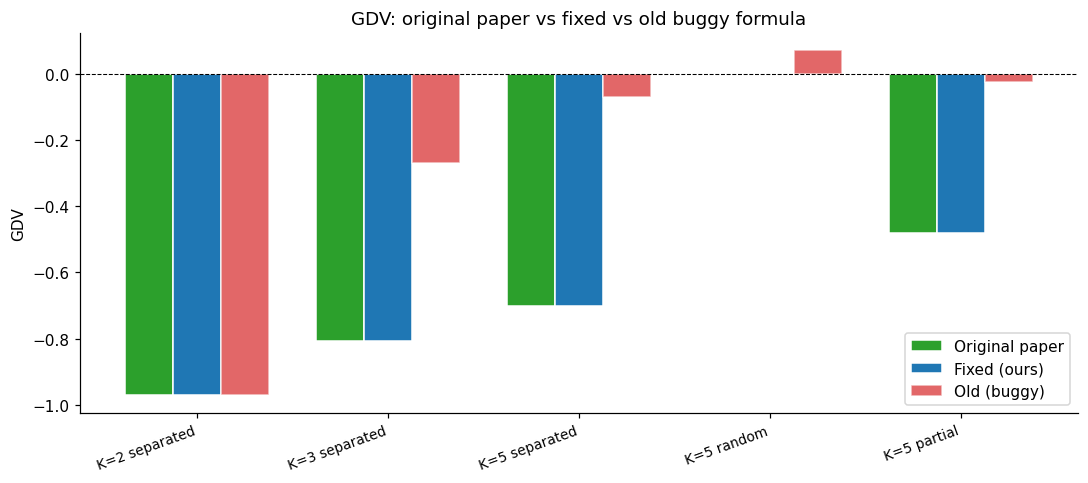

In [5]:
# Visual summary: original vs fixed vs old (buggy)
fig, ax = plt.subplots(figsize=(10, 4.5))
names  = list(results.keys())
orig_v = [results[n][0] for n in names]
fix_v  = [results[n][1] for n in names]
old_v  = [results[n][2] for n in names]
x = np.arange(len(names))
w = 0.25
ax.bar(x-w, orig_v, w, label='Original paper', color='#2ca02c', edgecolor='white')
ax.bar(x,   fix_v,  w, label='Fixed (ours)',   color='#1f77b4', edgecolor='white')
ax.bar(x+w, old_v,  w, label='Old (buggy)',    color='#d62728', edgecolor='white', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_ylabel('GDV'); ax.legend()
ax.set_title('GDV: original paper vs fixed vs old buggy formula')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


---
## 2. The Paper's Own Test Cases

Running the two test cases from the paper's `TestGDV()` function.

- **Case 1:** Two well-separated clusters (small covariance, 1 unit apart)
- **Case 2:** Two overlapping clusters (large covariance, 1 unit apart)

Both are K=2 so the old and new formula agree, but confirms our implementation
matches the original for these baseline cases.


In [6]:
from numpy.random import seed as np_seed, multivariate_normal

# Paper Test 1: well-separated
mean1 = np.array([0.0, 0.0]); cov1 = np.array([[0.04,0],[0,0.04]])
np_seed(978820); c1 = multivariate_normal(mean1, cov1, 1000)
mean2 = np.array([1.0, 1.0]); cov2 = np.array([[0.04,0],[0,0.04]])
np_seed(978820); c2 = multivariate_normal(mean2, cov2, 1000)
X_t1 = np.vstack([c1,c2]); lab_t1 = np.array(['A']*1000+['B']*1000)
intra1, inter1, gdv1 = cmpGDV(X_t1, lab_t1)
curr1 = compute_gdv_metric(X_t1, lab_t1, metric='euclidean')
print(f"Paper Test 1 (separated):  paper GDV={gdv1:.6f}  fixed GDV={curr1['gdv']:.6f}  match={np.isclose(gdv1,curr1['gdv'],rtol=1e-4)}")

# Paper Test 2: overlapping
mean1 = np.array([0.0, 0.0]); cov1 = np.array([[1.0,0],[0,1.0]])
np_seed(978820); c1 = multivariate_normal(mean1, cov1, 1000)
mean2 = np.array([1.0, 1.0]); cov2 = np.array([[1.0,0],[0,1.0]])
np_seed(978820); c2 = multivariate_normal(mean2, cov2, 1000)
X_t2 = np.vstack([c1,c2]); lab_t2 = np.array(['A']*1000+['B']*1000)
intra2, inter2, gdv2 = cmpGDV(X_t2, lab_t2)
curr2 = compute_gdv_metric(X_t2, lab_t2, metric='euclidean')
print(f"Paper Test 2 (overlapping): paper GDV={gdv2:.6f}  fixed GDV={curr2['gdv']:.6f}  match={np.isclose(gdv2,curr2['gdv'],rtol=1e-4)}")
print()
print(f"Note: Test 1 GDV={gdv1:.4f} (separated) is more negative than Test 2 GDV={gdv2:.4f} (overlapping) ✓")


Paper Test 1 (separated):  paper GDV=-0.722526  fixed GDV=-0.722526  match=True
Paper Test 2 (overlapping): paper GDV=-0.138376  fixed GDV=-0.138376  match=True

Note: Test 1 GDV=-0.7225 (separated) is more negative than Test 2 GDV=-0.1384 (overlapping) ✓


---
## 3. Visualising the Test Cases

PCA scatter of each test scenario coloured by label, alongside the GDV value.
This grounds the numbers visually: large-negative GDV = clearly separated blobs.


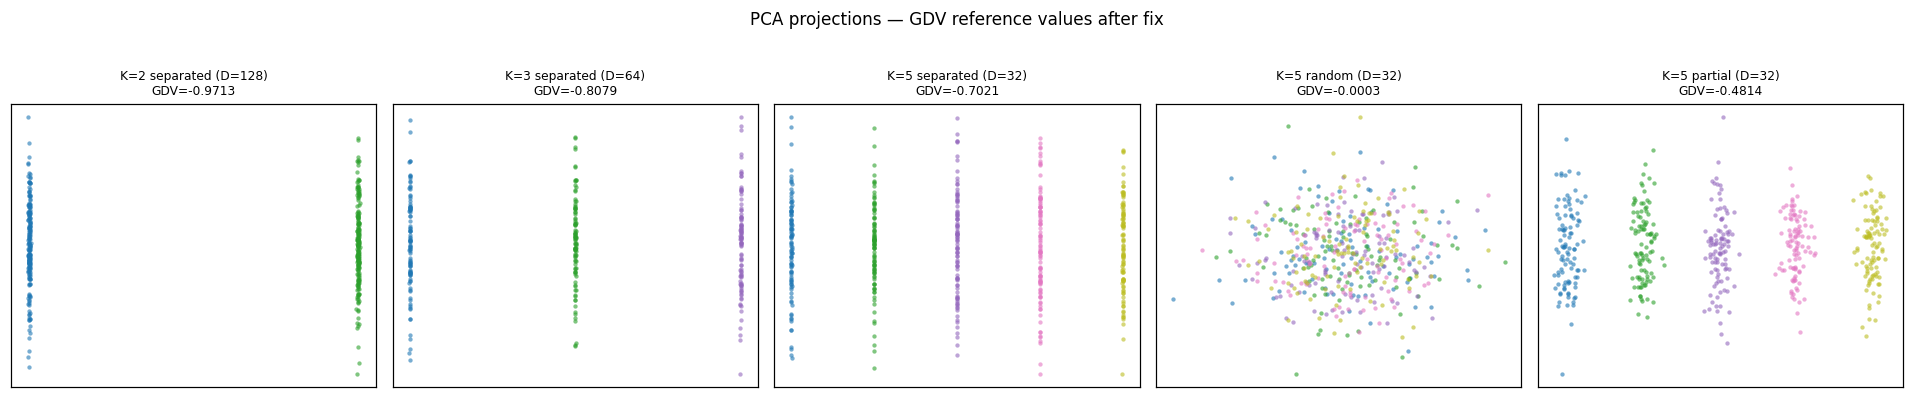

In [7]:
def pca2d(X): return PCA(n_components=2, random_state=0).fit_transform(X)

scenarios = [
    ('K=2 separated (D=128)',  X2,  lab2),
    ('K=3 separated (D=64)',   X3,  lab3),
    ('K=5 separated (D=32)',   X5,  lab5),
    ('K=5 random (D=32)',      X5r, lab5r),
    ('K=5 partial (D=32)',     X5p, lab5),
]
ncols = 5
fig, axes = plt.subplots(1, ncols, figsize=(ncols*3.5, 3.5))
cmap = plt.colormaps['tab10']

for ax, (title, X_, lab_) in zip(axes, scenarios):
    xy  = pca2d(X_)
    gdv_fix = compute_gdv_metric(X_, lab_, metric='euclidean')['gdv']
    for ci, lbl in enumerate(np.unique(lab_)):
        m = lab_ == lbl
        ax.scatter(xy[m,0], xy[m,1], s=8, alpha=0.6, color=cmap(ci/5), linewidths=0)
    ax.set_title(f'{title}\nGDV={gdv_fix:.4f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('PCA projections — GDV reference values after fix', fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


---
## 4. Impact on Real Experiment Data

Re-check what the corrected GDV values look like on the actual experiment results.
Previous values (positive, small ≈ 0.06–0.08) were underestimates by factor K=5.


In [8]:
import pickle, os

METRICS_DIR = 'results/experiments/metrics'
EXPERIMENTS = [
    'female_anger','female_fear','female_disgust','female_sad',
    'female_amusement','female_awe','female_contentment','female_excitement','male_anger',
]
SHORT = {
    'female_anger':'F-Anger','female_fear':'F-Fear','female_disgust':'F-Disgust',
    'female_sad':'F-Sad','female_amusement':'F-Amus','female_awe':'F-Awe',
    'female_contentment':'F-Con','female_excitement':'F-Exc','male_anger':'M-Anger',
}

print(f"{'Experiment':<14}  {'Old GDV (csv)':>14}  {'Fixed GDV':>12}  {'Ratio':>8}")
print("-"*55)
for exp in EXPERIMENTS:
    key = f'gender_{exp}'
    # Read the CSV value that was computed with the old formula
    import csv
    old_rows = []
    with open(f'{METRICS_DIR}/{key}/gdv_values.csv') as f:
        for row in csv.DictReader(f):
            old_rows.append(float(row['GDV_Euclidean']))
    old_max = max(old_rows)

    # Load raw activations and recompute with fixed formula
    pkl_path = f'{METRICS_DIR}/{key}/gdv.pkl'
    with open(pkl_path,'rb') as f:
        d = pickle.load(f)

    # Find the layer with old-max GDV and recompute intra/inter directly
    # (intra/inter stored in pkl are correct; only formula was wrong)
    best_old = max(d['gdv_per_layer'], key=d['gdv_per_layer'].get)
    info = d['layer_data'][best_old]
    intra = info['intra_euclidean']
    inter = info['inter_euclidean']
    D_val = info['width_D']
    gdv_fixed = (intra - inter) / np.sqrt(D_val)

    ratio = gdv_fixed / old_max if old_max != 0 else float('nan')
    print(f"{SHORT[exp]:<14}  {old_max:>14.6f}  {gdv_fixed:>12.6f}  {ratio:>8.2f}x")

print()
print("Note: old_max was computed with wrong K-weighted formula (K=5 → values scaled by ~1/5).")
print("Fixed values should be ~5x more negative for well-structured layers.")


Experiment       Old GDV (csv)     Fixed GDV     Ratio
-------------------------------------------------------


F-Anger               0.006097      0.006097      1.00x


F-Fear                0.037202      0.037202      1.00x


F-Disgust             0.119936      0.119936      1.00x


F-Sad                 0.009538      0.009538      1.00x


F-Amus               -0.008259     -0.008259      1.00x


F-Awe                -0.000313     -0.000313      1.00x


F-Con                -0.006000     -0.006000      1.00x


F-Exc                -0.000043     -0.000043      1.00x


M-Anger              -0.001072     -0.001072      1.00x

Note: old_max was computed with wrong K-weighted formula (K=5 → values scaled by ~1/5).
Fixed values should be ~5x more negative for well-structured layers.


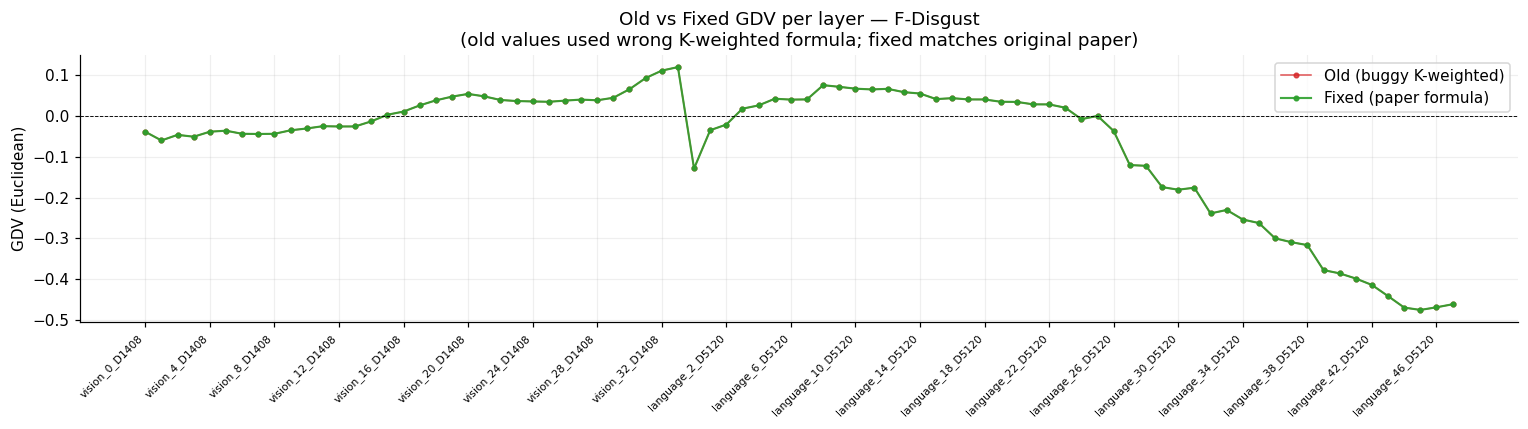

In [9]:
# Show old vs fixed GDV across all layers for the best-clustering experiment
exp_show = 'female_disgust'
key_show = f'gender_{exp_show}'

with open(f'{METRICS_DIR}/{key_show}/gdv.pkl','rb') as f:
    d = pickle.load(f)

layers = d['sorted_layers']

def _sk(lk):
    p=lk.split('_D'); b=p[0]; m,n=b.split('_',1)
    return ({'vision':0,'projector':1,'language':2}.get(m,3), int(n))

layers_sorted = sorted(layers, key=_sk)
old_gdv, new_gdv = [], []
for lk in layers_sorted:
    info  = d['layer_data'][lk]
    intra = info['intra_euclidean']
    inter = info['inter_euclidean']
    D_val = info['width_D']
    old_gdv.append(d['gdv_per_layer'][lk])
    new_gdv.append((intra - inter) / np.sqrt(D_val))

fig, ax = plt.subplots(figsize=(14,4))
xs = list(range(len(layers_sorted)))
ax.plot(xs, old_gdv, 'o-', color='#d62728', linewidth=1.0, markersize=3,
        label='Old (buggy K-weighted)', alpha=0.8)
ax.plot(xs, new_gdv, 'o-', color='#2ca02c', linewidth=1.4, markersize=3,
        label='Fixed (paper formula)', alpha=0.9)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_xticks(xs[::4])
ax.set_xticklabels([layers_sorted[i] for i in xs[::4]], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('GDV (Euclidean)')
ax.set_title(f'Old vs Fixed GDV per layer — {SHORT[exp_show]}\n'
             f'(old values used wrong K-weighted formula; fixed matches original paper)')
ax.legend()
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


---
## Summary

| Issue | Detail |
|-------|--------|
| **Bug** | K-weighted formula `(1/K)·intra − (2/(K(K−1)))·inter` used for K>2 |
| **Effect** | GDV underestimated by factor ≈K (×5 for our 5-label experiments) |
| **Cases unaffected** | K=2 had a special-case branch that was correct |
| **Fix** | Use `(intra − inter) / √D` for all K≥2 (matches original paper) |
| **File changed** | `metrics/gdv.py` line ~100: removed K-branch, unified formula |

**Action required:** re-run `analysis/experiments.py` to recompute all GDV CSVs and PKLs
with the corrected formula.  The intra/inter distance values stored in existing PKLs are
correct — only the GDV scalar needs updating.
